In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import pearsonr

In [2]:
df  = pd.read_csv('data/process/loan_data_cleaned.csv')
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets_value,loan_to_income_ratio,assets_to_loan_ratio,income_per_dependent,loan_per_term
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,50700000,3.114583,1.695652,3.200000e+06,2.491667e+06
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,17000000,2.975610,1.393443,4.100000e+06,1.525000e+06
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,57700000,3.263736,1.942761,2.275000e+06,1.485000e+06
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,52700000,3.743902,1.716612,2.050000e+06,3.837500e+06
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,55000000,2.469388,2.272727,1.633333e+06,1.210000e+06
5,6,0,1,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,33900000,2.812500,2.511111,4.800000e+06,1.350000e+06
6,7,5,1,0,8700000,33000000,4,678,22500000,14800000,29200000,4300000,1,70800000,3.793103,2.145455,1.450000e+06,8.250000e+06
7,8,2,1,1,5700000,15000000,20,382,13200000,5700000,11800000,6000000,0,36700000,2.631579,2.446667,1.900000e+06,7.500000e+05
8,9,0,1,1,800000,2200000,20,782,1300000,800000,2800000,600000,1,5500000,2.750000,2.500000,8.000000e+05,1.100000e+05
9,10,5,0,0,1100000,4300000,10,388,3200000,1400000,3300000,1600000,0,9500000,3.909091,2.209302,1.833333e+05,4.300000e+05


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   4269 non-null   int64  
 1   no_of_dependents          4269 non-null   int64  
 2   education                 4269 non-null   int64  
 3   self_employed             4269 non-null   int64  
 4   income_annum              4269 non-null   int64  
 5   loan_amount               4269 non-null   int64  
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   int64  
 9   commercial_assets_value   4269 non-null   int64  
 10  luxury_assets_value       4269 non-null   int64  
 11  bank_asset_value          4269 non-null   int64  
 12  loan_status               4269 non-null   int64  
 13  total_assets_value        4269 non-null   int64  
 14  loan_to_

In [4]:
df.describe()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets_value,loan_to_income_ratio,assets_to_loan_ratio,income_per_dependent,loan_per_term
count,4269.000000,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,0.502225,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160,3.254877e+07,2.984807,2.231797,2.055050e+06,2.194899e+06
std,1232.498479,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904,1.950656e+07,0.595496,0.643145,2.003233e+06,2.597537e+06
min,1.000000,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000,4.000000e+05,1.500000,0.750000,3.333333e+04,1.500000e+04
25%,1068.000000,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000,1.630000e+07,2.464286,1.767347,7.750000e+05,7.000000e+05
50%,2135.000000,3.000000,1.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000,3.150000e+07,3.000000,2.142857,1.450000e+06,1.357143e+06
75%,3202.000000,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000,4.720000e+07,3.500000,2.616216,2.500000e+06,2.516667e+06
max,4269.000000,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000,9.070000e+07,4.000000,5.666667,9.900000e+06,1.935000e+07


In [5]:
corr_matrix = df.corr()

In [6]:
corr_matrix

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets_value,loan_to_income_ratio,assets_to_loan_ratio,income_per_dependent,loan_per_term
loan_id,1.000000,0.005326,0.015536,0.001745,0.012592,0.008170,0.009809,0.016323,0.020936,0.018595,-0.000862,0.010765,0.017685,0.012555,-0.011235,0.007186,0.010837,-0.005401
no_of_dependents,0.005326,1.000000,0.002697,0.000765,0.007266,-0.003366,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163,-0.018114,0.005289,-0.029256,0.020927,-0.627381,0.010627
education,0.015536,0.002697,1.000000,-0.023224,0.011625,0.010631,-0.008417,-0.004649,0.010930,-0.006763,0.012471,0.009424,0.004918,0.009513,-0.004923,0.004820,0.010318,0.020108
self_employed,0.001745,0.000765,-0.023224,1.000000,0.002368,0.001450,0.004107,-0.004866,0.006144,-0.017998,0.004413,-0.000215,0.000345,0.000023,-0.004078,0.003889,-0.005566,-0.004513
income_annum,0.012592,0.007266,0.011625,0.002368,1.000000,0.927470,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093,-0.015189,0.931845,0.019714,0.016068,0.568127,0.467731
loan_amount,0.008170,-0.003366,0.010631,0.001450,0.927470,1.000000,0.008437,-0.017035,0.594596,0.603188,0.860914,0.788122,0.016150,0.867067,0.340791,-0.210844,0.530610,0.500970
loan_term,0.009809,-0.020111,-0.008417,0.004107,0.011488,0.008437,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177,-0.113036,0.010131,-0.002876,-0.017829,0.025654,-0.592993
cibil_score,0.016323,-0.009998,-0.004649,-0.004866,-0.023034,-0.017035,0.007810,1.000000,-0.019947,-0.003769,-0.028618,-0.015478,0.770518,-0.023433,0.002980,-0.003459,-0.008477,-0.019369
residential_assets_value,0.020936,0.007376,0.010930,0.006144,0.636841,0.594596,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418,-0.014367,0.790402,0.021176,0.319579,0.351763,0.284969
commercial_assets_value,0.018595,-0.001531,-0.006763,-0.017998,0.640328,0.603188,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576,0.008246,0.730576,0.029573,0.209195,0.372467,0.303705


In [7]:
sns.set_theme(style="darkgrid", palette="pastel")
plt.rcParams.update({
    "grid.color": "0.3",
    "axes.facecolor": "#1c1c1c",
    "figure.facecolor": "#121212",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

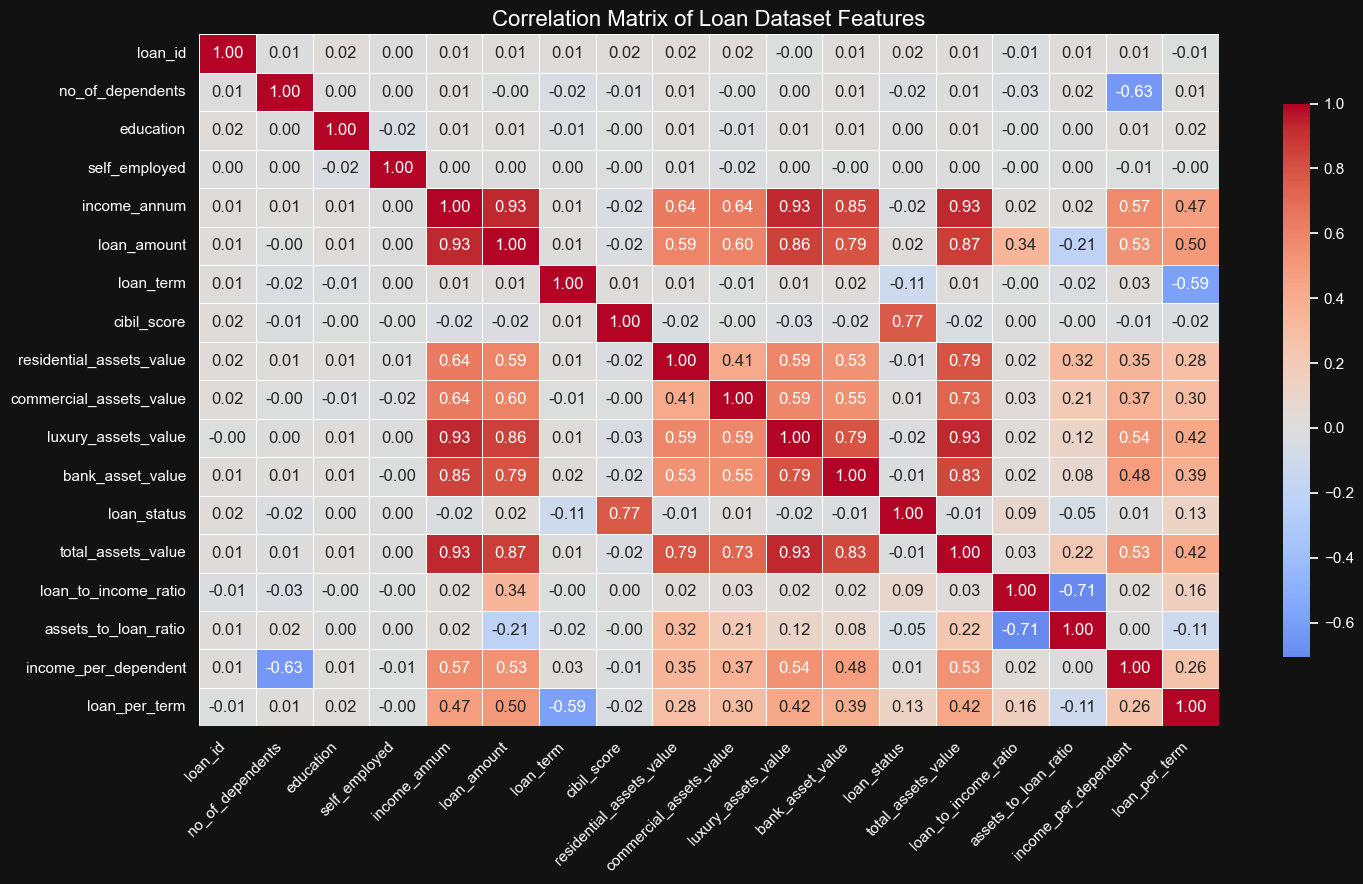

In [8]:
plt.figure(figsize=(15,9))

# 3. Generate a custom heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the correlation coefficients on the plot
    fmt=".2f",           # Format to 2 decimal places
    cmap='coolwarm',     # Color map from blue (negative) to red (positive)
    center=0,            # Set the middle value of the colormap to 0
    linewidths=0.5,      # Add lines between cells for better visibility
    cbar_kws={"shrink": .8} # Adjust the size of the color bar
)

# 4. Finalize plot details
plt.title('Correlation Matrix of Loan Dataset Features', fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels to prevent overlapping
plt.tight_layout()

# 5. Display the plot
plt.show()

## **Analysis 1 — Income vs Loan Amount**

Variables: 
- ```income_annum```
- ```loan_amount```

In [9]:
r, p_value = pearsonr(df['income_annum'], df['loan_amount'])
print(f"Hệ số tương quan r: {r}")
print(f"p-value: {p_value}")

Hệ số tương quan r: 0.9274699109871487
p-value: 0.0


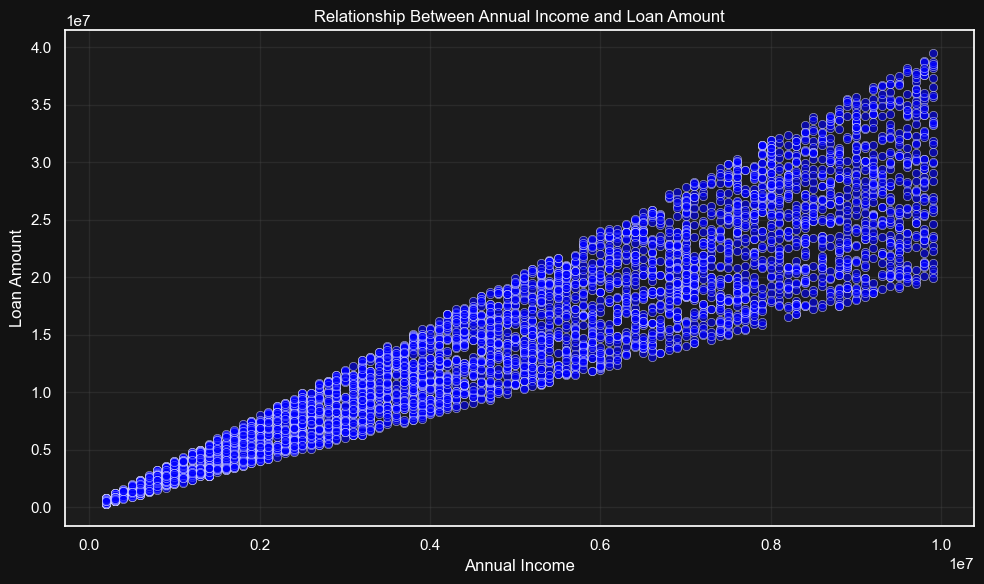

In [14]:
plt.figure(figsize=(10, 6))

# Scatter Plot
sns.scatterplot(
    data=df,
    x='income_annum',
    y='loan_amount',
    alpha=0.6,
    color='blue',
    edgecolor='w'
)

# Labels
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')

# Title
plt.title('Relationship Between Annual Income and Loan Amount')

# Grid
plt.grid(alpha=0.3)

# Layout
plt.tight_layout()

# Save figure
plt.savefig(
    "reports/images/pearson/income_vs_loan_amount.png",
    dpi=300,
    bbox_inches='tight'
)

# Show plot
plt.show()

## **Analysis 2 — Total Assets vs Bank Asset Value**

Variables:
- ```total_assets_value```
- ```bank_asset_value```

In [13]:
r_1, p_value_1 = pearsonr(df['total_assets_value'], df['bank_asset_value'])
print(f"Hệ số tương quan r: {r_1}")
print(f"p-value: {p_value_1}")

Hệ số tương quan r: 0.8338968228447515
p-value: 0.0


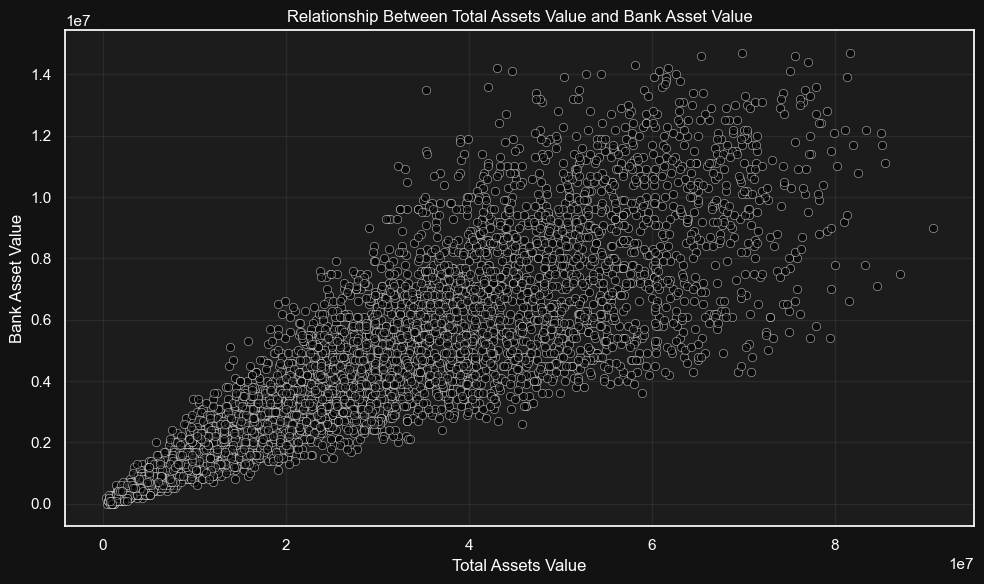

In [15]:
plt.figure(figsize=(10, 6))

# Scatter Plot
sns.scatterplot(
    data=df,
    x='total_assets_value',
    y='bank_asset_value',
    alpha=0.6,
    color='black',
    edgecolor='w'
)

# Labels
plt.xlabel('Total Assets Value')
plt.ylabel('Bank Asset Value')

# Title
plt.title('Relationship Between Total Assets Value and Bank Asset Value')

# Grid
plt.grid(alpha=0.3)

# Layout
plt.tight_layout()

# Save figure
plt.savefig(
    "reports/images/pearson/total_assets_value_vs_bank_asset_value.png",
    dpi=300,
    bbox_inches='tight'
)

# Show plot
plt.show()